In [4]:
import itertools
import collections
import gzip
import matplotlib.pyplot as plt
from pathlib import Path

In [17]:
def phred33_to_q(phred: str) -> int:
    """Converts phred 33 base to q"""
    return ord(phred) - 33

In [3]:
phred33_to_q("I")

40

In [10]:
if Path("./first1000.fq").exists():
    print("first1000.fq file already created")
else:
    with gzip.open(filename="./data/AlexisMoulin-SQ6388FJ-30x-WGS-Sequencing_com-05-19-26.1.fq.gz", mode="rt") as source:
        first_1000_lines = itertools.islice(source, 1000)
        with open(file="./first1000.fq", mode="w") as target:
            for line in first_1000_lines:
                target.write(line)

In [11]:
def readfastq(filename: str) -> tuple[list[str], list[str]]:
    sequences: list[str] = []
    qualities: list[str] = []
    with open(file=filename, mode="r") as fh:
        while True:
            fh.readline()
            seq = fh.readline().strip()
            fh.readline()
            qual = fh.readline().strip()

            if len(seq) == 0:
                break

            sequences.append(seq)
            qualities.append(qual)

    return sequences, qualities

In [12]:
seqs, quals = readfastq(filename="first1000.fq")
print(seqs[:5])
print(quals[:5])

['TTTCCACTGGAGGGTAAAGACTTGTGAGCAGCCAAATACAGAATGCCTTACCTTAATAGAAGTGGAAGATTTTTTCTACTCTTTTTAGTTTCCTCTGGGAAAATGATTACTATTTTTTAGTTTCATTACAACATTACTAGAATTCAAGTG', 'GTAACCTTGACACTCCTCGCATTGGGAGACGGCACCTATGCCTGCTCTCTCTTGAATCTGGGTGGACTTGTGATTTCTTTGACTAATAGGAATGGCGTGCTACACTGCAGTGCTAACTGAAAAACCGCCTGGCACTGCAAAGCCGAGATT', 'AATGTGCTCCCAGCTCTGCAGCAGTGGAGACGCAGTCAGTGGCACTGAGTGCTCCAGGGGTCACTGTAGAGTTGTGGTCTTTGTCCTTGCTGCCCCAAACCCACAGCTGTTAATTTATTAGGTTTTGTTAGAAGATACTCCCACACTAAA', 'GTAGATATGATGTAAATTATCCACATTTAGTGTCTTAAGGTAGGTTTATAGCTACAGGACCTGAGATGAGATACATGTGAAATTGATTCAACAAAGAAGATCTAGGGTTTGATATCAAGCCCTTTCTCATTTGTCTCCCATTTCCTCTTC', 'ATATTATTTGCAAATACCCTCTCCCATTCTGTGGGTTGTCTTTTCCCCTTTCTTGATGGTGTCCTTTGCAGTACAGCAGTTTTTAATTTTGGTGATGCCCAGTCAAAATGATATATTTTTTCTCTTTGGTTGCTCGTGTTTTTGGTGTTG']
['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII8IIIIIIIIIIIIIII8III

In [13]:
len(seqs), len(quals)

(250, 250)

In [14]:
for i in range(0, len(seqs)):
    if len(seqs[i]) != 150:
        print(f"read: {i} - sequences: {len(seqs[i])} - qualities: {len(quals[i])}")

read: 13 - sequences: 115 - qualities: 115
read: 33 - sequences: 125 - qualities: 125
read: 66 - sequences: 33 - qualities: 33
read: 82 - sequences: 148 - qualities: 148
read: 93 - sequences: 53 - qualities: 53
read: 96 - sequences: 143 - qualities: 143
read: 100 - sequences: 40 - qualities: 40
read: 132 - sequences: 117 - qualities: 117
read: 139 - sequences: 90 - qualities: 90
read: 162 - sequences: 139 - qualities: 139
read: 170 - sequences: 97 - qualities: 97
read: 173 - sequences: 122 - qualities: 122
read: 197 - sequences: 116 - qualities: 116
read: 219 - sequences: 61 - qualities: 61


In [15]:
def create_hist(qualities: list[str]) -> list[int]:
    hist = [0] * 50
    for qual in qualities:
        for phred in qual:
            q = phred33_to_q(phred)
            hist[q] += 1

    return hist

In [18]:
h = create_hist(quals)
print(h)

[5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 415, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 491, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 35888, 0, 0, 0, 0, 0, 0, 0, 0, 0]


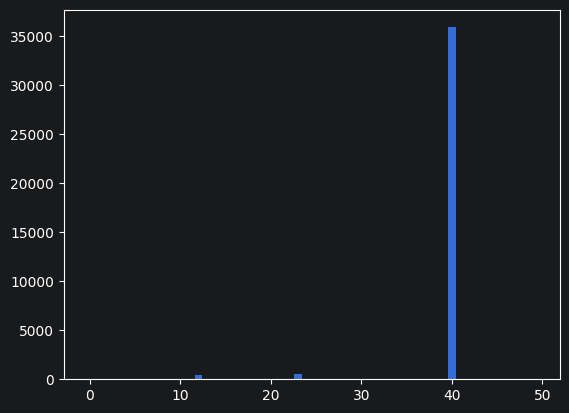

In [19]:
plt.bar(x=range(len(h)), height=h)
plt.show()

In [20]:
def find_gc_by_pos(reads: list[str]) -> list[float]:
    gc = [0] * 150
    totals = [0] * 150
    for read in reads:
        for i in range(len(read)):
            if read[i] == "C" or read[i] == "G":
                gc[i] += 1
            totals[i] += 1

    for i in range(len(gc)):
        if totals[i] > 0:
            gc[i] /= float(totals[i])

    return gc

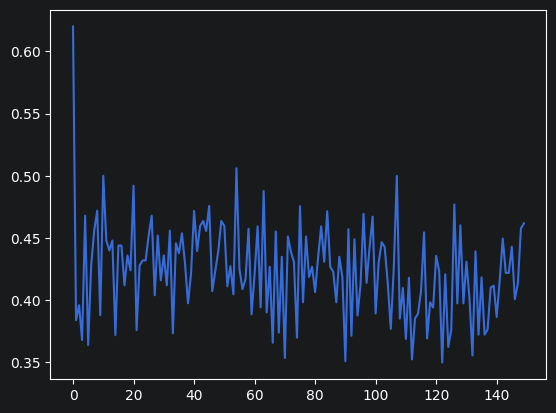

In [21]:
gc = find_gc_by_pos(seqs)

plt.plot(range(len(gc)), gc)
plt.show()

In [22]:
count = collections.Counter()
for seq in seqs:
    count.update(seq)

print(count)

Counter({'A': 10653, 'T': 10531, 'G': 7953, 'C': 7657, 'N': 5})
